<a href="https://colab.research.google.com/github/mousse-26/telco-customer-churn-prediction/blob/main/ANN_2025em1100144.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Customer Churn Prediction using Neural Network

This notebook analyses customer data and builds a neural network model to predict churn. The goal is also to understand customer behaviour and suggest business actions.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/ANN/telco_churn.csv'
df = pd.read_csv(file_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Data Understanding

The dataset contains information about telecom customers, including their services, billing details, and basic demographics.

The target variable is **Churn**, which shows whether a customer has left the service or not. Since it has two possible values (Yes/No), this becomes a binary classification problem.

Looking at the dataset before building the model is important, as it helps in understanding which features might affect customer churn and if there are any issues in the data.

In [ ]:
df.info()
df.describe()
df['Churn'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,count
Churn,
No,5174
Yes,1869


### Data Cleaning and Preprocessing

In this step, the dataset was cleaned to ensure better model performance.

The `TotalCharges` column was converted to numeric format since it was stored as text. Missing values were handled by replacing them with the median to avoid losing data.

The `customerID` column was removed because it does not contribute to prediction.

Categorical variables were converted into numerical form using encoding so that they can be used in the neural network.

These steps help in preparing the data for training and improving model performance.

In [ ]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop customerID
df.drop('customerID', axis=1, inplace=True)

# Convert target
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

/tmp/ipykernel_4682/492299826.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Churn', axis=1)
y = df['Churn']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Exploratory Data Analysis

In this section, patterns in the data are explored to understand factors affecting churn.

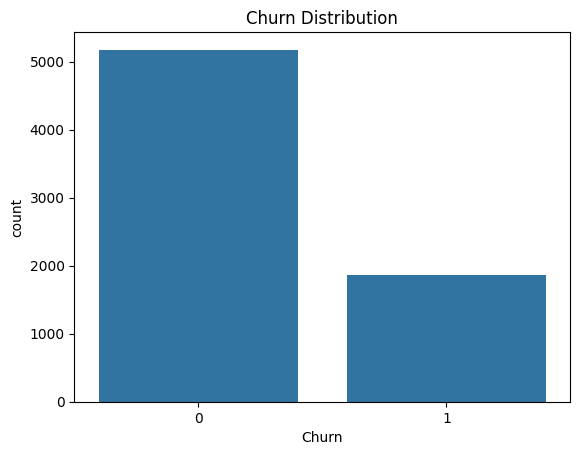

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)
plt.title("Churn Distribution")
plt.show()

Customers with churn = Yes are fewer compared to those who stayed, indicating a slight class imbalance.

This is important because imbalanced data can affect model performance.

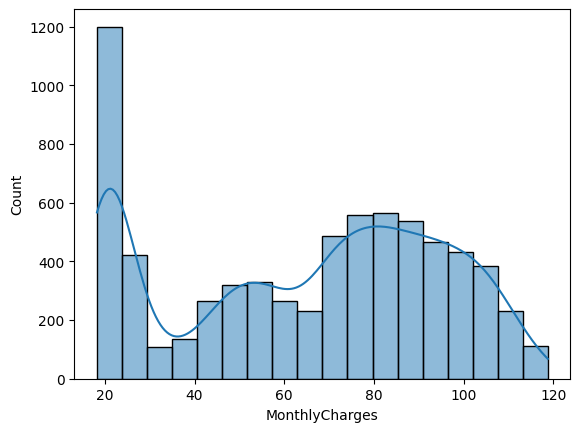

In [ ]:
sns.histplot(df['MonthlyCharges'], kde=True)
plt.show()

Customers with higher monthly charges appear to churn more frequently.

This suggests that pricing may influence customer satisfaction and retention.

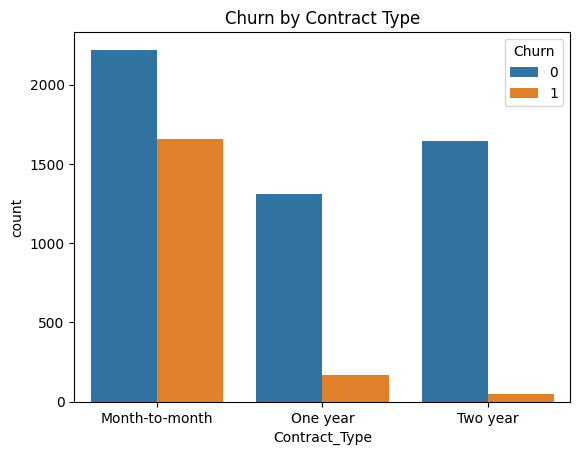

In [ ]:
def get_contract_type(row):
    if 'Contract_One year' in row.index and row['Contract_One year'] == 1:
        return 'One year'
    elif 'Contract_Two year' in row.index and row['Contract_Two year'] == 1:
        return 'Two year'
    else:
        return 'Month-to-month'

# Create a temporary column for plotting based on the dummified contract columns
df['Contract_Type'] = df.apply(get_contract_type, axis=1)

sns.countplot(x='Contract_Type', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

# Drop the temporary column to keep the DataFrame consistent for subsequent steps
df.drop('Contract_Type', axis=1, inplace=True)

Customers with month-to-month contracts have higher churn compared to long-term contracts.

This indicates that long-term commitment reduces churn.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

### Neural Network Model

A simple neural network was chosen instead of a complex model because the objective is to understand patterns in the data rather than just maximise accuracy.

Using a simpler architecture also helps reduce overfitting and makes the model easier to interpret.

ReLU activation is used in the hidden layers to introduce non-linearity, while sigmoid activation is used in the output layer since this is a binary classification problem.

Binary crossentropy is used as the loss function because it is suitable for binary classification tasks.

Overall, this setup is sufficient for capturing basic relationships in the dataset.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(32, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7593 - loss: 0.4905 - val_accuracy: 0.8012 - val_loss: 0.4294
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7932 - loss: 0.4340 - val_accuracy: 0.8119 - val_loss: 0.4215
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7963 - loss: 0.4269 - val_accuracy: 0.7968 - val_loss: 0.4203
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7974 - loss: 0.4216 - val_accuracy: 0.8110 - val_loss: 0.4168
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8008 - loss: 0.4171 - val_accuracy: 0.8048 - val_loss: 0.4149
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8014 - loss: 0.4147 - val_accuracy: 0.8075 - val_loss: 0.4130
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8019 - loss: 0.4128 - val_accuracy: 0.8101 - val_loss: 0.4115
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8050 - loss: 0.4102 - val_accuracy: 0.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = (model.predict(X_test) > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[939  97]
 [159 214]]
              precision    recall  f1-score   support

           0       0.86      0.91      0.88      1036
           1       0.69      0.57      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



### Model Evaluation and Interpretation

The model achieves a reasonable accuracy, but accuracy alone is not enough to fully evaluate performance.

From the confusion matrix, it can be seen that the model sometimes fails to correctly identify churned customers.

This is important because:
- False negatives (predicting a customer will stay when they actually leave) are costly.
- The company may lose these customers without taking any action.

Overall, the model is able to capture general patterns in the data, but there is still room for improvement, especially in identifying churn cases.

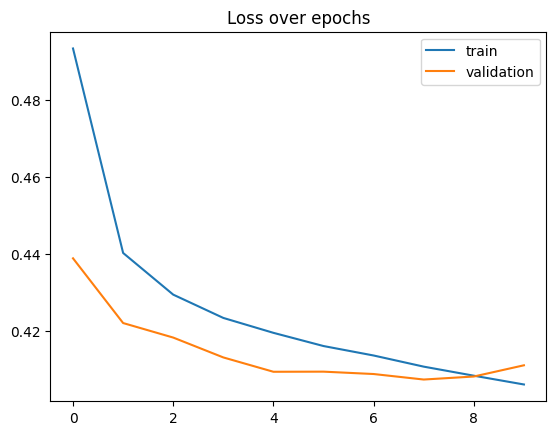

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss over epochs')
plt.legend(['train', 'validation'])
plt.show()

### From Insight to Decision

Based on the analysis, the following actions can be taken:

#### Decision 1:
The company can target customers with month-to-month contracts and offer incentives such as discounts or benefits to encourage them to switch to long-term plans.

- Assumption: Customers are influenced by pricing and contract benefits.
- Risk: Discounts may reduce short-term revenue.

#### Decision 2:
Customers can be encouraged to use additional services like tech support and security features to increase engagement with the service.

- Assumption: Higher engagement leads to better retention.
- Risk: Customers may not find these services useful or necessary.

#### Limitations:
These strategies may not work if customers are leaving mainly due to poor service quality rather than pricing or features.